# Downstream Tasks and Model Verification


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from astropy.table import Table
import matplotlib.colors as mcolors
from matplotlib.widgets import Slider
from numpy.lib.stride_tricks import sliding_window_view

from SpecML import D_emb, SpecML
%matplotlib widget

#imports for plots

In [2]:
from SpecML import load_specml
from Tokeniser import f, dq, w, valid_spectrum, valid_spectra, tokenize
#imports from model

In [3]:
def encode_all(mask, bs=256):
    Xm, Vm = X[mask], V[mask]
    P_t = torch.from_numpy(P).float().to(device)
    out = []
    with torch.no_grad():
        for i in range(0, len(Xm), bs):
            xb = torch.from_numpy(Xm[i:i+bs]).float().to(device)
            vb = torch.from_numpy(Vm[i:i+bs]).bool().to(device)
            out.append(model.encode(xb, vb, P_t).cpu())
    return torch.cat(out, dim=0)

### Redshift Prediction Plot

Load Data and Data Cleaning Process

In [4]:
catalog = Table.read('dja_msaexp_emission_lines_v4.5.csv.gz', format='ascii')
catalog = catalog[catalog['grating'] == 'PRISM']
catalog = catalog[valid_spectrum][valid_spectra]   # match BOTH filters Tokeniser applies to f
mask_g3 = np.array(
    (np.array(catalog['grade'].filled(0)) == 3) & (np.array(catalog['z_best']) >= 0)
)
z_g3 = torch.from_numpy(np.array(catalog['z_best'][mask_g3], dtype=np.float32))

In [5]:
# ── Model + tokenisation setup 
MODEL_FILE = 'SpecML.pt'

device = ('cuda' if torch.cuda.is_available() else
          'mps'  if torch.backends.mps.is_available() else 'cpu')

model, cfg = load_specml(MODEL_FILE, device=device)
print(cfg)   # patch_size, overlap, D_emb, n_layers ... all read from the .pt

# Tokenise the raw flux with the exact patch params the model was trained with
f_norm = (f - f.mean(axis=1, keepdims=True)) / f.std(axis=1, keepdims=True).clip(1e-10)
X, V, P = tokenize(f_norm, dq, w, cfg['patch_size'], cfg['overlap'], cfg['D_emb'])
print(f'X: {X.shape},  V: {V.shape},  P: {P.shape}')

{'patch_dim': 6, 'patch_size': 4, 'overlap': 2, 'step': 2, 'D_emb': 512, 'n_heads': 8, 'n_layers': 10, 'ffn_dim': 2048}
X: (42195, 233, 6),  V: (42195, 233),  P: (233, 512)


Encode grade-3 spectra with frozen model

In [ ]:
# device = 'cpu'
# if torch.cuda.is_available():
#     device = 'cuda'
# if torch.backends.mps.is_available():
#     device = 'mps'

# patch_size = 10
# model_file = 'SpecML.pt'
# #hardcode patch size to match from file because one in tokensier wont match, will have to hardcode demb as well

# model = SpecML(patch_dim = patch_size + 2).to(device)
# model.load_state_dict(torch.load('SpecML.pt', map_location=device, weights_only=True))
# model.eval()
Xg = X[mask_g3]
Vg = V[mask_g3]
P_t = torch.from_numpy(P).float().to(device)

# bs = 256  # lower to 128/64 if you still OOM
# embs = []
# with torch.no_grad():
#     for i in range(0, len(Xg), bs):
#         xb = torch.from_numpy(Xg[i:i+bs]).float().to(device)
#         vb = torch.from_numpy(Vg[i:i+bs]).bool().to(device)
#         embs.append(model.encode(xb, vb, P_t).cpu())
#         # torch.mps.empty_cache()  # uncomment if memory still creeps up
emb = encode_all(mask_line)

# with torch.no_grad():
#     emb = model.encode(
#         torch.from_numpy(X[mask_g3]).float().to(device),
#         torch.from_numpy(V[mask_g3]).bool().to(device),
#         torch.from_numpy(P).float().to(device),
#     ).cpu()

# ---- 50/50 train/test split -------------------------------------------------
n = len(z_g3)
idx = torch.randperm(n, generator=torch.Generator().manual_seed(42))
split = n // 2
emb_train, emb_test = emb[idx[:split]], emb[idx[split:]]
z_train, z_test = z_g3[idx[:split]], z_g3[idx[split:]]

z_mean, z_std = z_train.mean(), z_train.std()
z_train_n = (z_train - z_mean) / z_std

# ---- Linear head, encoder frozen --------------------------------------------
head = nn.Sequential(nn.LayerNorm(cfg['D_emb']), nn.Linear(cfg['D_emb'], 1))
opt = torch.optim.AdamW(head.parameters(), lr=1e-2)

head.train()
for step in range(2000):
    batch = torch.randint(len(emb_train), (256,))
    loss = F.mse_loss(head(emb_train[batch]).squeeze(-1), z_train_n[batch])
    opt.zero_grad(); loss.backward(); opt.step()

if step % 200 == 0:
    print(f'step {step:4d}  loss {loss.item():.4f}')

head.eval()
with torch.no_grad():
    z_pred = head(emb_test).squeeze(-1) * z_std + z_mean

dz = (z_pred - z_test).abs() / (1 + z_test)
print(f'grade-3 test set:  N={len(z_test)}')
print(f'MAE                {(z_pred - z_test).abs().mean().item():.4f}')
print(f'median |Δz|/(1+z)  {dz.median().item():.4f}')

Plotting Redshift Prediction

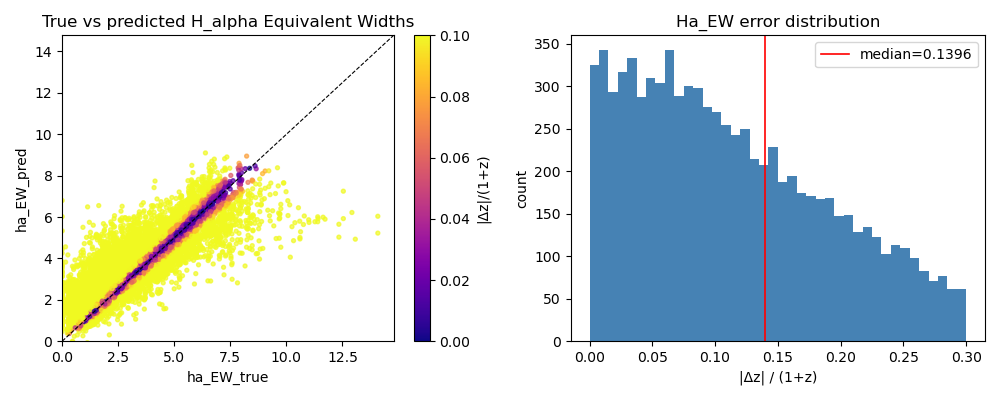

Saved downstream_linear_Ha_EW.png


In [ ]:
z_true_np = z_test.numpy()
z_pred_np = z_pred.numpy()
dz_np = dz.numpy()

#i think i need to add a random seed to this, because it keeps returning a different median each time when it shouldnt because its drawing from the same specml.pt file
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ax = axes[0]
lim = (0, max(z_true_np.max(), z_pred_np.max()) * 1.05)
ax.scatter(
    z_true_np, z_pred_np, c=dz_np, cmap='plasma', s=8, alpha=0.7, vmin=0, vmax=0.1
)
ax.plot(lim, lim, 'k--', lw=0.8)
ax.set_xlim(lim)
ax.set_ylim(lim)
ax.set_xlabel('ha_EW_true')
ax.set_ylabel('ha_EW_pred')
ax.set_title('True vs predicted H_alpha Equivalent Widths')
sm = plt.cm.ScalarMappable(cmap='plasma', norm=plt.Normalize(0, 0.1))
fig.colorbar(sm, ax=ax, label='|Δz|/(1+z)')

ax = axes[1]
ax.hist(dz_np, bins=40, range=(0, 0.3), color='steelblue', edgecolor='none')
ax.axvline(
    float(dz.median()), color='red', lw=1.2, label=f'median={float(dz.median()):.4f}'
)
ax.set_xlabel('|Δz| / (1+z)')
ax.set_ylabel('count')
ax.set_title('Ha_EW error distribution')
ax.legend()

plt.tight_layout()
plt.savefig('downstream_linea_Ha_EW.png', dpi=150)
plt.show()
print('Saved downstream_linear_Ha_EW.png')

### Line Ha NII Prediction

In [ ]:
# ---- Ha+NII line-flux probe (reuses model / cfg / X / V / P / device from setup) ----
# catalog must already be the DOUBLE-filtered one from cell 4: [valid_spectrum][valid_spectra]
snr = (np.array(catalog['line_ha_nii'],     dtype=np.float32) /
       np.array(catalog['line_ha_nii_err'], dtype=np.float32).clip(1e-30))
mask_line = np.isfinite(snr) & (snr >= 3) & (np.array(catalog['line_ha_nii'], dtype=np.float32) > 0)
line = torch.from_numpy(np.array(catalog['line_ha_nii'][mask_line], dtype=np.float32))

Xl = X[mask_line]
Vl = V[mask_line]
P_t = torch.from_numpy(P).float().to(device)

emb = encode_all(mask_line)

# bs = 256  # drop to 128/64 if it still OOMs
# embs = []
# with torch.no_grad():
#     for i in range(0, len(Xl), bs):
#         xb = torch.from_numpy(Xl[i:i+bs]).float().to(device)
#         vb = torch.from_numpy(Vl[i:i+bs]).bool().to(device)
#         embs.append(model.encode(xb, vb, P_t).cpu())
#         # torch.mps.empty_cache()  # uncomment if memory still creeps up
# emb = torch.cat(embs, dim=0)

# with torch.no_grad():
#     emb = model.encode(
#         torch.from_numpy(X[mask_line]).float().to(device),
#         torch.from_numpy(V[mask_line]).bool().to(device),
#         torch.from_numpy(P).float().to(device),
#     ).cpu()

n = len(line)
idx = torch.randperm(n, generator=torch.Generator().manual_seed(42))
split = n // 2
emb_train, emb_test   = emb[idx[:split]], emb[idx[split:]]
line_train, line_test = line[idx[:split]], line[idx[split:]]

line_mean, line_std = line_train.mean(), line_train.std()
line_train_n = (line_train - line_mean) / line_std

head_line = nn.Sequential(nn.LayerNorm(cfg['D_emb']), nn.Linear(cfg['D_emb'], 1))
opt = torch.optim.AdamW(head_line.parameters(), lr=1e-2)

head_line.train()
for step in range(2000):
    batch = torch.randint(len(emb_train), (256,))
    loss = F.mse_loss(head_line(emb_train[batch]).squeeze(-1), line_train_n[batch])
    opt.zero_grad(); loss.backward(); opt.step()
    if step % 200 == 0:
        print(f'step {step:4d}  loss {loss.item():.4f}')

head_line.eval()
with torch.no_grad():
    line_pred = head_line(emb_test).squeeze(-1) * line_std + line_mean

err = (line_pred - line_test).abs()
print(f'Ha+NII test set:  N={len(line_test)}')
print(f'MAE               {err.mean().item():.4f}')

/var/folders/zd/2rbx916x3vn4xr9snljfn9s9xmb1gn/T/ipykernel_31234/3280152017.py:3: RuntimeWarning: overflow encountered in divide
  snr = (np.array(catalog['line_ha_nii'],     dtype=np.float32) /
Error: command buffer exited with error status.
	The Metal Performance Shaders operations encoded on it may not have completed.
	Error: 
	(null)
	Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory)
	<AGXG16GFamilyCommandBuffer: 0x3a6d6fdf0>
    label = <none> 
    device = <AGXG16GDevice: 0x42700d800>
        name = Apple M4 
    commandQueue = <AGXG16GFamilyCommandQueue: 0x147f1d600>
        label = <none> 
        device = <AGXG16GDevice: 0x42700d800>
            name = Apple M4 
    retainedReferences = 1


RuntimeError: Invalid buffer size: 30.06 GiB

In [ ]:
# ---- Plot: Ha+NII line-flux prediction ----
lt = line_test.numpy()
lp = line_pred.numpy()
er = err.numpy()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: predicted vs true (diagonal = perfect)
ax = axes[0]
lim = (min(lt.min(), lp.min()), max(lt.max(), lp.max()))
ax.scatter(lt, lp, c=er, cmap='plasma', s=8, alpha=0.7)
ax.plot(lim, lim, 'k--', lw=0.8)
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel('Ha+NII flux (true)')
ax.set_ylabel('Ha+NII flux (predicted)')
ax.set_title('True vs predicted Ha+NII line flux')
fig.colorbar(plt.cm.ScalarMappable(cmap='plasma',
    norm=plt.Normalize(er.min(), er.max())), ax=ax, label='|error|')

# Right: actual (under) vs predicted (over), sorted by true flux for readability
ax = axes[1]
order = np.argsort(lt)
x = np.arange(len(lt))
ax.plot(x, lt[order], color='steelblue', lw=1.0, label='actual')
ax.plot(x, lp[order], color='tomato', lw=0.7, alpha=0.75, label='predicted')
ax.set_xlabel('test spectra (sorted by true flux)')
ax.set_ylabel('Ha+NII flux')
ax.set_title('Actual vs predicted')
ax.legend()

plt.tight_layout()
plt.savefig('downstream_ha_nii.png', dpi=150)
plt.show()
print('Saved downstream_ha_nii.png')

NameError: name 'line_test' is not defined

### BPT Prediction

In [ ]:
MODEL_FILE   = 'SpecML.pt'
MIN_SNR      = 3.0    # S/N floor for all four BPT emission lines
Z_BIN        = 0.25   # half-width of the redshift window shown per slider tick
Z_SLIDER_MIN = 1.0    # slider left edge (z = 1)


# Load spectra + catalogue, then tokenise with correct patch size
fits_data = Table.read(
    'https://s3.amazonaws.com/msaexp-nirspec/extractions/dja_msaexp_emission_lines_v4.5.prism_spectra.fits',
    cache=True,
)
catalog = Table.read('dja_msaexp_emission_lines_v4.5.csv.gz', format='ascii')
catalog = catalog[catalog['grating'] == 'PRISM']

# Validity masks (mirrors Tokeniser.py logic)
valid_w        = np.any(fits_data['valid'], 1)   # (n_wavelengths,)
valid_spectrum = np.any(fits_data['valid'], 0)   # (n_spectra,)

w      = fits_data['wave'][valid_w]
f_raw  = fits_data['flux'][np.ix_(valid_w, valid_spectrum)].T / (w**2)
dq     = fits_data['valid'][np.ix_(valid_w, valid_spectrum)].T   # (B, L)

# Drop spectra with zero variance (constant / all-NaN)
keep_std  = np.std(f_raw, axis=1) > 0.0
f_raw     = f_raw[keep_std]
dq        = dq[keep_std]
cat_align = catalog[valid_spectrum][keep_std]   # row-aligned with f_raw

device = ('cuda' if torch.cuda.is_available() else
          'mps'  if torch.backends.mps.is_available() else 'cpu')
model, cfg = load_specml(MODEL_FILE, device=device)
PATCH_SIZE, OVERLAP, STEP, D_EMB = (
    cfg['patch_size'], cfg['overlap'], cfg['step'], cfg['D_emb'])
print(cfg)

# Per-spectrum z-score normalisation
mu     = np.mean(f_raw, axis=1, keepdims=True)
sigma  = np.std( f_raw, axis=1, keepdims=True).clip(1e-10)
f_norm = (f_raw - mu) / sigma

# Patchify  →  (B, T, patch_size)
x_t   = sliding_window_view(f_norm, PATCH_SIZE, axis=1)[:, ::STEP]
X_all = np.concatenate([
    np.nanmean(x_t, axis=2, keepdims=True),
    np.nanstd( x_t, axis=2, keepdims=True),
    x_t,
], axis=2).astype(np.float32)                          # (B, T, P+2)

dq_p  = sliding_window_view(dq, PATCH_SIZE, axis=1)[:, ::STEP]
V_all = dq_p.all(axis=2)                               # (B, T)
X_all[~V_all] = 0.0

# Wavelength positional encoding
T       = X_all.shape[1]
w_pat   = sliding_window_view(w, PATCH_SIZE)[::STEP].mean(axis=1)[:T]
omegas  = 10000 ** (-2 * np.arange(D_EMB // 2) / D_EMB)
product = np.outer(w_pat * 1e4, omegas)
P_enc   = np.empty((T, D_EMB), dtype=np.float32)
P_enc[:, 0::2] = np.sin(product)
P_enc[:, 1::2] = np.cos(product)

print(f'Spectra loaded: {len(X_all)},  patch tokens per spectrum: {T}')


# Batch-encode all spectra with frozen SpecML


P_t  = torch.from_numpy(P_enc).to(device)
embs = []
with torch.no_grad():
    for i in range(0, len(X_all), 512):
        e = model.encode(
            torch.from_numpy(X_all[i:i+512]).float().to(device),
            torch.from_numpy(V_all[i:i+512]).bool().to(device),
            P_t,
        )
        embs.append(e.cpu())
embs = torch.cat(embs)
print(f'Embeddings: {embs.shape}')


# BPT quality cuts and compute true log line ratios
def _col(name, fill=np.nan):
    c = cat_align[name]
    arr = np.array(c.filled(fill) if hasattr(c, 'filled') else c, dtype=np.float32)
    arr[~np.isfinite(arr)] = fill
    return arr

def _err(name, fill=np.inf):
    c = cat_align[name]
    arr = np.array(c.filled(fill) if hasattr(c, 'filled') else c, dtype=np.float32)
    arr[~np.isfinite(arr) | (arr <= 0)] = fill
    return arr

# ---- Emission-line ratios (PRISM proxy BPT: SII vs OIII/Hb) ----
hb_f   = _col('line_hb');          hb_e   = _err('line_hb_err')
oiii_f = _col('line_oiii_5007');   oiii_e = _err('line_oiii_5007_err')
sii_f  = _col('line_sii');         sii_e  = _err('line_sii_err')        # doublet already summed
han_f  = _col('line_ha_nii');      han_e  = _err('line_ha_nii_err')     # Ha+NII blend (PRISM)
z_all  = _col('z_best', fill=-1.0)

keep_bpt = (
    (hb_f   / hb_e   >= MIN_SNR) & (oiii_f / oiii_e >= MIN_SNR) &
    (sii_f  / sii_e  >= MIN_SNR) & (han_f  / han_e  >= MIN_SNR) &
    (hb_f > 0) & (oiii_f > 0) & (sii_f > 0) & (han_f > 0) &
    (z_all >= Z_SLIDER_MIN)
)

# x-axis is a PRISM proxy: denominator is Ha+NII blended, NOT pure Ha
log_sii_han = np.log10(sii_f[keep_bpt]  / han_f[keep_bpt]).astype(np.float32)
log_oiii_hb = np.log10(oiii_f[keep_bpt] / hb_f[keep_bpt]).astype(np.float32)
z_bpt       = z_all[keep_bpt]
embs_bpt    = embs[np.where(keep_bpt)[0]]

finite = np.isfinite(log_sii_han) & np.isfinite(log_oiii_hb)
log_sii_han = log_sii_han[finite]
log_oiii_hb = log_oiii_hb[finite]
z_bpt       = z_bpt[finite]
embs_bpt    = embs_bpt[finite]

if len(z_bpt) == 0:
    raise ValueError('No galaxies pass the cuts — loosen MIN_SNR or Z_SLIDER_MIN.')
Z_SLIDER_MAX = float(z_bpt.max())
print(f'Galaxies: {len(embs_bpt)},  z range: {z_bpt.min():.2f} – {Z_SLIDER_MAX:.2f}')



{'patch_dim': 6, 'patch_size': 4, 'overlap': 2, 'step': 2, 'D_emb': 512, 'n_heads': 8, 'n_layers': 10, 'ffn_dim': 2048}
Spectra loaded: 42195,  patch tokens per spectrum: 233


In [ ]:
for nm, m in [('hb', hb_f/hb_e>=MIN_SNR), ('oiii', oiii_f/oiii_e>=MIN_SNR),
              ('sii', sii_f/sii_e>=MIN_SNR), ('ha_nii', han_f/han_e>=MIN_SNR),
              ('z>=min', z_all>=Z_SLIDER_MIN)]:
    print(f'{nm:8s}: {int(np.asarray(m).sum())}')
print('keep_bpt:', int(keep_bpt.sum()))

hb      : 8794
oiii    : 6627
sii     : 7103
ha_nii  : 22542
z>=min  : 19629
keep_bpt: 821


  step    0  loss_x 1.1737  loss_y 0.9409
  step  500  loss_x 0.2759  loss_y 0.5386
  step 1000  loss_x 0.2604  loss_y 0.4524
  step 1500  loss_x 0.2196  loss_y 0.4154
  step 2000  loss_x 0.2441  loss_y 0.3810
  step 2500  loss_x 0.2223  loss_y 0.3546

Test MAE  log(NII/Hα):   0.1253
Test MAE  log(OIII/Hβ): 0.0868


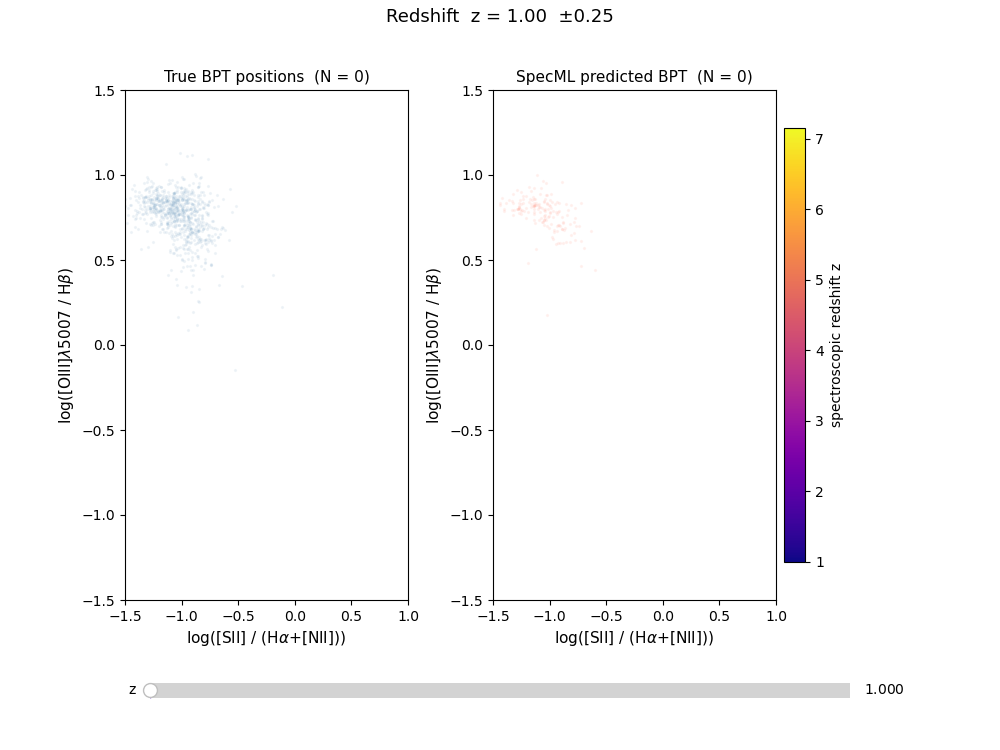

In [ ]:

# Train linear probes for both BPT axes (encoder frozen)
n     = len(embs_bpt)
perm  = torch.randperm(n, generator=torch.Generator().manual_seed(42))
split = int(0.8 * n)
tr, te = perm[:split].numpy(), perm[split:].numpy()

emb_tr = embs_bpt[tr];  emb_te = embs_bpt[te]
x_tr   = torch.from_numpy(log_sii_han[tr])
y_tr   = torch.from_numpy(log_oiii_hb[tr])
x_te   = torch.from_numpy(log_sii_han[te])
y_te   = torch.from_numpy(log_oiii_hb[te])
z_te   = z_bpt[te]

# Normalise targets for stable training
xm, xs = x_tr.mean(), x_tr.std()
ym, ys = y_tr.mean(), y_tr.std()

head_x = nn.Sequential(nn.LayerNorm(D_EMB), nn.Linear(D_EMB, 1))
head_y = nn.Sequential(nn.LayerNorm(D_EMB), nn.Linear(D_EMB, 1))
opt = torch.optim.AdamW(
    list(head_x.parameters()) + list(head_y.parameters()), lr=1e-2
)

for step in range(3000):
    b  = torch.randint(len(emb_tr), (512,))
    lx = F.mse_loss(head_x(emb_tr[b]).squeeze(), (x_tr[b] - xm) / xs)
    ly = F.mse_loss(head_y(emb_tr[b]).squeeze(), (y_tr[b] - ym) / ys)
    (lx + ly).backward()
    opt.step()
    opt.zero_grad()
    if step % 500 == 0:
        print(f'  step {step:4d}  loss_x {lx.item():.4f}  loss_y {ly.item():.4f}')

head_x.eval(); head_y.eval()
with torch.no_grad():
    x_pred = head_x(emb_te).squeeze() * xs + xm
    y_pred = head_y(emb_te).squeeze() * ys + ym

x_true_np = x_te.numpy();   y_true_np = y_te.numpy()
x_pred_np = x_pred.numpy(); y_pred_np = y_pred.numpy()
print(f'\nTest MAE  log(NII/Hα):   {np.abs(x_pred_np - x_true_np).mean():.4f}')
print(f'Test MAE  log(OIII/Hβ): {np.abs(y_pred_np - y_true_np).mean():.4f}')



# Interactive BPT diagram with redshift slider

# Demarcation lines from BPT.py

XLIM = (-1.5, 1.0)
YLIM = (-1.5, 1.5)

fig = plt.figure(figsize=(10, 7.5))
plt.subplots_adjust(bottom=0.20, wspace=0.3)
ax_true = fig.add_subplot(1, 2, 1)
ax_pred = fig.add_subplot(1, 2, 2)

for ax in (ax_true, ax_pred):
    ax.set_xlim(*XLIM);  ax.set_ylim(*YLIM)
    ax.set_xlabel(r'log([SII] / (H$\alpha$+[NII]))', fontsize=11)
    ax.set_ylabel(r'log([OIII]$\lambda$5007 / H$\beta$)', fontsize=11)
    # Shade AGN region label

# Faint background: all BPT-valid true positions (left) / all test predictions (right)
ax_true.scatter(log_sii_han, log_oiii_hb, s=2, alpha=0.06,
                color='steelblue', zorder=1, rasterized=True)
ax_pred.scatter(x_pred_np, y_pred_np,     s=2, alpha=0.06,
                color='tomato',    zorder=1, rasterized=True)

# Foreground scatter objects updated by the slider
cmap = plt.cm.plasma
norm = mcolors.Normalize(vmin=Z_SLIDER_MIN, vmax=Z_SLIDER_MAX)

sc_tr = ax_true.scatter([], [], s=22, c=[], cmap=cmap, norm=norm,
                        edgecolors='k', linewidths=0.2, zorder=4)
sc_pr = ax_pred.scatter([], [], s=22, c=[], cmap=cmap, norm=norm,
                        edgecolors='k', linewidths=0.2, zorder=4)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
fig.colorbar(sm, ax=[ax_true, ax_pred], label='spectroscopic redshift z',
             shrink=0.85, pad=0.01)

# Redshift slider
ax_sl  = fig.add_axes([0.15, 0.06, 0.70, 0.04])
slider = Slider(ax_sl, 'z', Z_SLIDER_MIN, Z_SLIDER_MAX,
                valinit=Z_SLIDER_MIN, valstep=0.05, color='mediumpurple')

def _update(val):
    zc  = slider.val
    sel = (z_te >= zc - Z_BIN) & (z_te <= zc + Z_BIN)
    n_s = int(sel.sum())

    sc_tr.set_offsets(np.c_[x_true_np[sel], y_true_np[sel]])
    sc_tr.set_array(z_te[sel])
    sc_pr.set_offsets(np.c_[x_pred_np[sel], y_pred_np[sel]])
    sc_pr.set_array(z_te[sel])

    ax_true.set_title(f'True BPT positions  (N = {n_s})', fontsize=11)
    ax_pred.set_title(f'SpecML predicted BPT  (N = {n_s})', fontsize=11)
    fig.suptitle(
        f'Redshift  z = {zc:.2f}  ±{Z_BIN}',
        fontsize=13, y=0.99
    )
    fig.canvas.draw_idle()

slider.on_changed(_update)
_update(Z_SLIDER_MIN)
plt.show()


#### SFR, Gas Metallicity and Dust Attenuation (Balmer Decrament)

In [ ]:
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u

print([c for c in cat_align.colnames if 'oii' in c.lower() and 'oiii' not in c.lower()])
print('line_oii present:', 'line_oii' in cat_align.colnames)

# ---- knobs ----
FLUX_UNIT_SCALE = 1.0          # multiply catalog flux to get erg/s/cm^2 (set if columns are scaled)
COSMO = FlatLambdaCDM(H0=70, Om0=0.3)
HA_HB_INTRINSIC = 2.86         # Case B, T=1e4 K
K_HA = 2.53                    # Calzetti k(Ha)
K_HB = 3.61                    # Calzetti k(Hb)
R_V  = 4.05

# ---- lines (clean where possible, proxy where forced) ----
hb_f    = _col('line_hb');         hb_e    = _err('line_hb_err')
oiii5_f = _col('line_oiii_5007');  oiii5_e = _err('line_oiii_5007_err')
oiii4_f = _col('line_oiii_4959');  oiii4_e = _err('line_oiii_4959_err')
oii_f = _col('line_oii');  oii_e = _err('line_oii_err')
han_f   = _col('line_ha_nii');     han_e   = _err('line_ha_nii_err')   # PROXY for Ha
z_all   = _col('z_best', fill=-1.0)

# require the lines each property needs, at S/N >= MIN_SNR, z valid
snr = lambda f, e: f / e
base_ok = (z_all >= Z_SLIDER_MIN) & (z_all >= 0)

# --- 1) Metallicity: R23 (CLEAN, no Ha) ---
m_metal = base_ok & (snr(hb_f,hb_e)>=MIN_SNR) & (snr(oiii5_f,oiii5_e)>=MIN_SNR) \
                   & (snr(oii_f,oii_e)>=MIN_SNR) & (hb_f>0)&(oiii5_f>0)&(oii_f>0)
R23      = (oiii5_f + oiii4_f + oii_f) / hb_f          # 4959 added if present, else ~0
logR23   = np.log10(R23, where=R23>0, out=np.full_like(R23, np.nan))

# --- 2) Balmer decrement (PROXY: numerator is Ha+NII) ---
m_balmer = base_ok & (snr(han_f,han_e)>=MIN_SNR) & (snr(hb_f,hb_e)>=MIN_SNR) & (hb_f>0)&(han_f>0)
balmer_proxy = han_f / hb_f                             # (Ha+NII)/Hb  — OVERESTIMATES dust
# colour excess from the (proxy) decrement
EBV_proxy = (2.5 / (K_HB - K_HA)) * np.log10(balmer_proxy / HA_HB_INTRINSIC)
EBV_proxy = np.clip(EBV_proxy, 0, None)                 # negative E(B-V) unphysical -> 0

# --- 3) SFR (PROXY: Ha+NII, dust-corrected, needs distance+cosmology) ---
m_sfr = m_balmer & (han_f>0)
dL_cm = COSMO.luminosity_distance(np.clip(z_all,1e-4,None)).to(u.cm).value
A_ha  = K_HA * EBV_proxy                                # mag of extinction at Ha
ha_corr = han_f * FLUX_UNIT_SCALE * 10**(0.4*A_ha)      # dust-corrected proxy Ha flux
L_ha    = 4*np.pi * dL_cm**2 * ha_corr                  # erg/s
SFR_proxy = 7.9e-42 * L_ha                              # Kennicutt 1998 (Msun/yr)
logSFR_proxy = np.log10(SFR_proxy, where=SFR_proxy>0, out=np.full_like(SFR_proxy, np.nan))

print(f'metallicity (R23, clean): {int(m_metal.sum())}')
print(f'balmer decrement (proxy): {int(m_balmer.sum())}')
print(f'SFR (proxy):              {int(m_sfr.sum())}')

['line_oii', 'line_oii_7325', 'line_oii_7325_err', 'line_oii_err', 'line_oii_7323', 'line_oii_7323_err', 'line_oii_7332', 'line_oii_7332_err', 'eqw_oii', 'eqw_oii_7325', 'eqw_oii_7323', 'eqw_oii_7332', 'phot_LOII']
line_oii present: True
metallicity (R23, clean): 1884
balmer decrement (proxy): 7657
SFR (proxy):              7657


/var/folders/zd/2rbx916x3vn4xr9snljfn9s9xmb1gn/T/ipykernel_84977/1699011872.py:30: RuntimeWarning: divide by zero encountered in divide
  R23      = (oiii5_f + oiii4_f + oii_f) / hb_f          # 4959 added if present, else ~0
/var/folders/zd/2rbx916x3vn4xr9snljfn9s9xmb1gn/T/ipykernel_84977/1699011872.py:30: RuntimeWarning: invalid value encountered in divide
  R23      = (oiii5_f + oiii4_f + oii_f) / hb_f          # 4959 added if present, else ~0
/var/folders/zd/2rbx916x3vn4xr9snljfn9s9xmb1gn/T/ipykernel_84977/1699011872.py:35: RuntimeWarning: divide by zero encountered in divide
  balmer_proxy = han_f / hb_f                             # (Ha+NII)/Hb  — OVERESTIMATES dust
/var/folders/zd/2rbx916x3vn4xr9snljfn9s9xmb1gn/T/ipykernel_84977/1699011872.py:35: RuntimeWarning: invalid value encountered in divide
  balmer_proxy = han_f / hb_f                             # (Ha+NII)/Hb  — OVERESTIMATES dust
/var/folders/zd/2rbx916x3vn4xr9snljfn9s9xmb1gn/T/ipykernel_84977/1699011872.py:37: Runtime

In [ ]:
def train_probe(values, mask, seed=42, steps=3000, lr=1e-2):
    """Linear probe: predict `values` from frozen embeddings, on rows where mask & finite."""
    m = np.asarray(mask) & np.isfinite(values)
    idx_all = np.where(m)[0]
    emb = embs[idx_all]
    y   = torch.from_numpy(values[idx_all].astype(np.float32))
    z   = z_all[idx_all]

    n = len(idx_all)
    perm = torch.randperm(n, generator=torch.Generator().manual_seed(seed))
    split = int(0.8 * n)
    tr, te = perm[:split], perm[split:]

    emb_tr, emb_te = emb[tr], emb[te]
    y_tr,  y_te    = y[tr],  y[te]
    z_te = z[te.numpy()]

    ym, ys = y_tr.mean(), y_tr.std().clip(1e-8)
    head = nn.Sequential(nn.LayerNorm(D_EMB), nn.Linear(D_EMB, 1))
    opt  = torch.optim.AdamW(head.parameters(), lr=lr)

    head.train()
    for step in range(steps):
        b = torch.randint(len(emb_tr), (512,))
        loss = F.mse_loss(head(emb_tr[b]).squeeze(-1), (y_tr[b] - ym) / ys)
        opt.zero_grad(); loss.backward(); opt.step()

    head.eval()
    with torch.no_grad():
        pred = head(emb_te).squeeze(-1) * ys + ym
    mae = (pred - y_te).abs().mean().item()
    return dict(true=y_te.numpy(), pred=pred.numpy(), z=z_te, mae=mae, n=n)

probes = {
    'log R23  (metallicity, clean)':        train_probe(logR23,       m_metal),
    'log (Hα+NII)/Hβ  (Balmer, PROXY)':     train_probe(np.log10(balmer_proxy,
                                                where=balmer_proxy>0,
                                                out=np.full(balmer_proxy.shape, np.nan)), m_balmer),
    'log SFR  (PROXY)':                     train_probe(logSFR_proxy, m_sfr),
}
for name, r in probes.items():
    print(f'{name:38s}  N={r["n"]:5d}  test MAE={r["mae"]:.4f}')

log R23  (metallicity, clean)           N= 1884  test MAE=0.0763
log (Hα+NII)/Hβ  (Balmer, PROXY)        N= 7657  test MAE=0.1028
log SFR  (PROXY)                        N= 7657  test MAE=0.3401


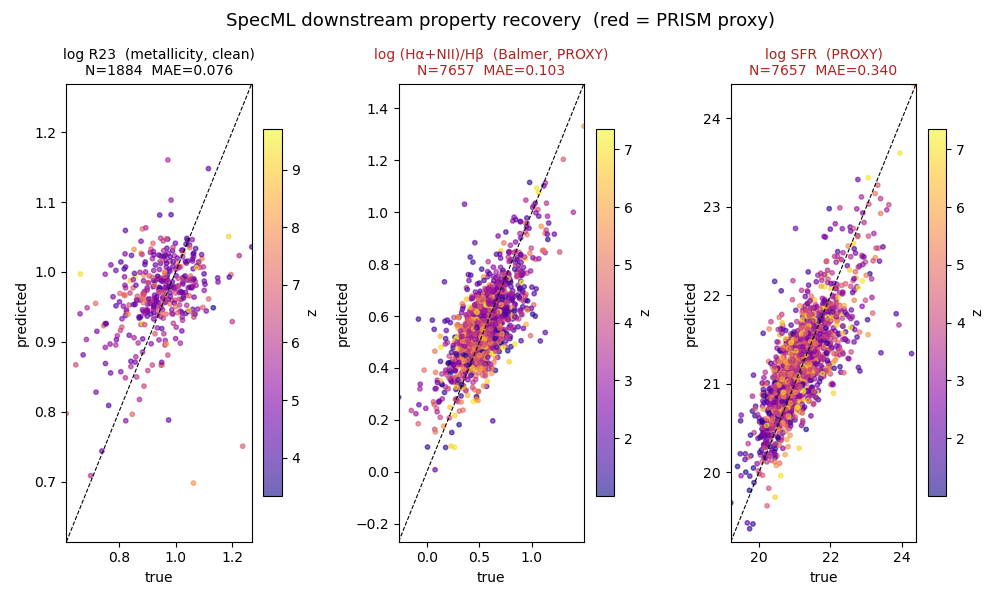

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(10, 6))
for ax, (name, r) in zip(axes, probes.items()):
    t, p = r['true'], r['pred']
    is_proxy = 'PROXY' in name
    lim = (min(t.min(), p.min()), max(t.max(), p.max()))
    sc = ax.scatter(t, p, c=r['z'], cmap='plasma', s=10, alpha=0.6)
    ax.plot(lim, lim, 'k--', lw=0.8)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel('true');  ax.set_ylabel('predicted')
    ax.set_title(f'{name}\nN={r["n"]}  MAE={r["mae"]:.3f}',
                 color=('firebrick' if is_proxy else 'black'), fontsize=10)
    fig.colorbar(sc, ax=ax, label='z', shrink=0.8)
fig.suptitle('SpecML downstream property recovery  (red = PRISM proxy)', fontsize=13)
plt.tight_layout()
plt.savefig('downstream_properties.png', dpi=150, bbox_inches='tight')
plt.show()

### Predicting Anomalies 